<a href="https://colab.research.google.com/github/sic-pilot08/NN-from-Scratch/blob/main/NN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np

In [10]:
class NeuralNetwork():
  def __init__(self, X, y, layers):
    self.X = X
    self.y = y
    self.layers = layers
    self.parameters = self.initialize_parameters()

  def init_kaiming_weights(self):
    pass

  def forward_prop(self, X, parameters):
    pass

  def compute_cost(self, y, probs, parameters):
    pass

  def back_prop(self, cache, parameters, y):
    pass

  def update_parameters(self, parameters, grads):
    pass

  def main(self, X, y, num_iter=1000):
    pass

if __name__ == '__main__':
  pass

Iteration 0: Cost = 1.258500791234629
Iteration 100: Cost = 0.6357859956488329
Iteration 200: Cost = 0.42330780956275477
Iteration 300: Cost = 0.3097484701017125
Iteration 400: Cost = 0.23914870640426802
Iteration 500: Cost = 0.19304025439217684
Iteration 600: Cost = 0.16072177500934917
Iteration 700: Cost = 0.13725987544889862
Iteration 800: Cost = 0.11819204793935431
Iteration 900: Cost = 0.10308408978010149


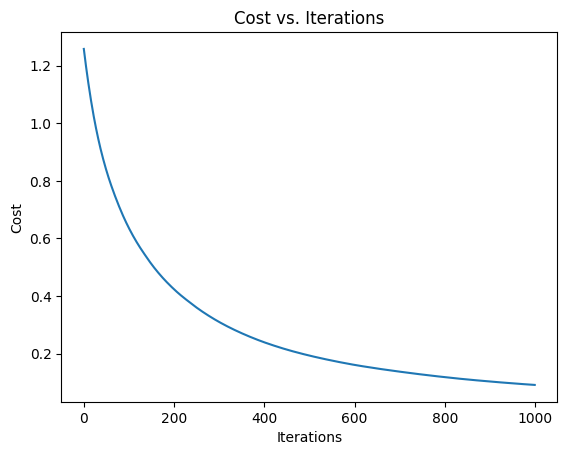

Training Accuracy: 97.5%
Test Accuracy: 100.0%


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class NeuralNetwork:
    def __init__(self, X, y, layers):
        self.X = X
        self.y = y
        self.layers = layers
        self.parameters = self.initialize_parameters()

    def initialize_parameters(self):
        parameters = {}
        for l in range(1, len(self.layers)):
            parameters['W' + str(l)] = np.random.randn(self.layers[l], self.layers[l-1]) * np.sqrt(2. / self.layers[l-1])  # He initialization
            parameters['b' + str(l)] = np.zeros((self.layers[l], 1))
        return parameters

    def forward_prop(self, X, parameters):
        cache = {'A0': X}
        L = len(parameters) // 2  # number of layers in the neural network

        for l in range(1, L + 1):
            W = parameters['W' + str(l)]
            b = parameters['b' + str(l)]
            A_prev = cache['A' + str(l-1)]

            Z = np.dot(W, A_prev) + b
            A = self.sigmoid(Z) if l == L else self.relu(Z)
            cache['Z' + str(l)] = Z
            cache['A' + str(l)] = A

        return cache

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def relu(self, Z):
        return np.maximum(0, Z)

    def compute_cost(self, y, cache):
        m = y.shape[1]
        A_final = cache['A' + str(len(self.layers)-1)]
        cost = (-1 / m) * np.sum(y * np.log(A_final) + (1 - y) * np.log(1 - A_final))
        return cost

    def back_prop(self, cache, parameters, X, y):
        grads = {}
        m = X.shape[1]
        L = len(parameters) // 2
        A_final = cache['A' + str(L)]
        A_prev = cache['A' + str(L-1)]

        dZ = A_final - y
        for l in reversed(range(1, L + 1)):
            dW = (1 / m) * np.dot(dZ, cache['A' + str(l-1)].T)
            db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
            grads['dW' + str(l)] = dW
            grads['db' + str(l)] = db

            if l > 1:
                dZ = np.dot(parameters['W' + str(l)].T, dZ) * self.relu_derivative(cache['Z' + str(l-1)])

        return grads

    def sigmoid_derivative(self, Z):
        return self.sigmoid(Z) * (1 - self.sigmoid(Z))

    def relu_derivative(self, Z):
        return Z > 0

    def update_parameters(self, parameters, grads, learning_rate=0.01):
        L = len(parameters) // 2
        for l in range(1, L + 1):
            parameters['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
            parameters['b' + str(l)] -= learning_rate * grads['db' + str(l)]
        return parameters

    def main(self, X_train, y_train, X_test, y_test, num_iter=1000, learning_rate=0.01):
        costs = []
        for i in range(num_iter):
            cache = self.forward_prop(X_train, self.parameters)
            cost = self.compute_cost(y_train, cache)
            grads = self.back_prop(cache, self.parameters, X_train, y_train)
            self.parameters = self.update_parameters(self.parameters, grads, learning_rate)
            costs.append(cost) # Cost is appended here
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost}")
            #costs.append(cost) # This line is removed to avoid double appending

        # Plot the cost
        plt.plot(np.arange(num_iter), costs)
        plt.xlabel("Iterations")
        plt.ylabel("Cost")
        plt.title("Cost vs. Iterations")
        plt.show()

        # Calculate accuracy for train and test sets
        train_accuracy = self.compute_accuracy(X_train, y_train)
        test_accuracy = self.compute_accuracy(X_test, y_test)

        print(f"Training Accuracy: {train_accuracy}%")
        print(f"Test Accuracy: {test_accuracy}%")

    def compute_accuracy(self, X, y):
        cache = self.forward_prop(X, self.parameters)
        A_final = cache['A' + str(len(self.layers)-1)]
        predictions = (A_final > 0.5).astype(int)
        accuracy = np.mean(predictions == y) * 100
        return accuracy

# Load and preprocess the dataset
iris = datasets.load_iris()
X = iris.data.T  # Transposed to match (features x samples)
y = (iris.target == 0).astype(int).reshape(1, -1)  # Binary classification for Iris-setosa (0 vs. 1)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X.T, y.T, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the neural network structure
layers = [X_train.shape[1], 5, 1]

# Create and train the neural network
nn = NeuralNetwork(X_train.T, y_train.T, layers)
nn.main(X_train.T, y_train.T, X_test.T, y_test.T, num_iter=1000, learning_rate=0.01)
